# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

In [14]:
agg_df.printSchema()

# 1. Leemos los archivos Parquet de la carpeta de resultados como un DataFrame estático
df_resultados = spark.read.parquet("resultados/")

# 2. Ahora sí podemos realizar las operaciones de conteo
total_filas = df_resultados.count()
total_sensores = df_resultados.select("sensor_id").distinct().count()

print(f"El dataframe tiene {total_filas} filas.")
print(f"Hay un total de {total_sensores} sensores distintos.")

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

El dataframe tiene 68 filas.
Hay un total de 4 sensores distintos.


### Ejercicio 2

In [20]:
df_resultados = df_resultados.withColumn('rango_metrica', df_resultados['avg_value'] - df_resultados['avg_temp'])

df_resultados.select("rango_metrica").summary("min", "max", "mean").show()

+-------+-------------------+
|summary|      rango_metrica|
+-------+-------------------+
|    min| -45.75749999999999|
|    max|-3.0166666666666693|
|   mean|-24.325194775404334|
+-------+-------------------+



### Ejercicio 3

In [34]:
df_filtrado = (df_resultados
               .filter(df_resultados["avg_value"] > 10)
               .filter(df_resultados["sensor_id"] == "S4")
               .filter(df_resultados["rango_metrica"] < 10))

print(f"Hay un total de {df_filtrado.count()} filas que cumplen las 3 restricciones")

Hay un total de 17 filas que cumplen las 3 restricciones


### Ejercicio 4

In [37]:
resumen_sensores = df_resultados.groupBy("sensor_id").agg({
    "rango_metrica": "avg", 
    "avg_temp": "max",
    "sensor_id": "count"
})

resumen_sensores.orderBy(avg("rango_metrica").desc()).show()

+---------+----------------+------------------+-------------------+
|sensor_id|count(sensor_id)|     max(avg_temp)| avg(rango_metrica)|
+---------+----------------+------------------+-------------------+
|       S1|              17|           61.6825|-23.765913186486717|
|       S2|              17|63.693333333333335| -23.93912145370969|
|       S3|              17|            73.936|-24.630066590272474|
|       S4|              17|           69.9275|-24.965677871148458|
+---------+----------------+------------------+-------------------+



### Ejercicio 5

In [38]:
df_resultados.createOrReplaceTempView("tabla_ventanas")

query_max_por_sensor = """
SELECT * FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY sensor_id ORDER BY avg_value DESC) as ranking
    FROM tabla_ventanas
) WHERE ranking = 1
"""

df_top_por_sensor = spark.sql(query_max_por_sensor)

df_top_por_sensor.show()


print("Sensor con el valor máximo global:")
df_top_por_sensor.orderBy("avg_value", ascending=False).select("sensor_id", "avg_value").limit(1).show()

+--------------------+---------+------------------+-----------------+-----------------+----------+-------------------+-------+
|              window|sensor_id|         avg_value|         avg_temp|     avg_humidity|num_events|      rango_metrica|ranking|
+--------------------+---------+------------------+-----------------+-----------------+----------+-------------------+-------+
|{2026-02-03 19:48...|       S1|36.402857142857144|57.28285714285715|55.01714285714286|         7|-20.880000000000003|      1|
|{2026-02-03 19:47...|       S2|35.909000000000006|           60.205|           65.389|        10|-24.295999999999992|      1|
|{2026-02-03 19:47...|       S3| 35.73285714285714|62.86285714285715|51.24857142857143|         7| -27.13000000000001|      1|
|{2026-02-03 19:41...|       S4|            37.682|44.12500000000001|           55.737|        10| -6.443000000000005|      1|
+--------------------+---------+------------------+-----------------+-----------------+----------+-------------

### Ejercicio 6

In [39]:
datos_sensores = [
    ("S1", "Planta A", "Temperatura"),
    ("S2", "Planta A", "Presión"),
    ("S3", "Planta B", "Temperatura"),
    ("S4", "Planta B", "Humedad")
]


df_info = spark.createDataFrame(datos_sensores, ["sensor_id", "ubicacion", "tipo"])

df_unido = df_resultados.join(df_info, on="sensor_id", how="inner")

df_unido.show(5)

+---------+--------------------+------------------+------------------+------------------+----------+-------------------+---------+-----------+
|sensor_id|              window|         avg_value|          avg_temp|      avg_humidity|num_events|      rango_metrica|ubicacion|       tipo|
+---------+--------------------+------------------+------------------+------------------+----------+-------------------+---------+-----------+
|       S1|{2026-02-03 19:49...|32.698750000000004|           61.6825|           57.1425|         8|-28.983749999999993| Planta A|Temperatura|
|       S1|{2026-02-03 19:47...|35.300000000000004|50.419999999999995| 60.24333333333334|         6| -15.11999999999999| Planta A|Temperatura|
|       S1|{2026-02-03 19:42...|           22.9175| 46.43999999999999| 71.53999999999999|         4| -23.52249999999999| Planta A|Temperatura|
|       S1|{2026-02-03 19:49...| 32.78666666666667| 52.90555555555555|54.111111111111114|         9|-20.118888888888883| Planta A|Temperatura|

### Ejercicio 7

In [40]:
df_resultados.createOrReplaceTempView("tabla_temporal2")

query_tiempo = """
SELECT 
    date_trunc('hour', window.start) as unidad_temporal,
    count(*) as total_ventanas,
    avg(avg_humidity) as humedad_media
FROM tabla_temporal2
GROUP BY unidad_temporal
ORDER BY unidad_temporal ASC
"""

df_tiempo = spark.sql(query_tiempo)

df_tiempo.show()

+-------------------+--------------+-----------------+
|    unidad_temporal|total_ventanas|    humedad_media|
+-------------------+--------------+-----------------+
|2026-02-03 19:00:00|            68|56.71396057863705|
+-------------------+--------------+-----------------+



### Ejercicio 8

In [42]:
df_reparticionado = df_resultados.repartition(5, "sensor_id")

df_con_particion = df_reparticionado.selectExpr("*", "spark_partition_id() AS partition_id")

# ¿Cuál es la distribución de registros entre las particiones?
df_con_particion.groupBy("partition_id").count().orderBy("partition_id").show()

+------------+-----+
|partition_id|count|
+------------+-----+
|           2|   17|
|           3|   34|
|           4|   17|
+------------+-----+



### Ejercicio 9

In [43]:
media_global = df_resultados.selectExpr("avg(avg_value)").collect()[0][0]

umbral_superior = media_global * 1.20
umbral_inferior = media_global * 0.80

print(f"Media global: {media_global:.2f}")
print(f"Criterio anomalía: > {umbral_superior:.2f} o < {umbral_inferior:.2f}")

df_anomalias = df_resultados.filter(
    (df_resultados["avg_value"] > umbral_superior) | 
    (df_resultados["avg_value"] < umbral_inferior)
)

# 3. Respondemos: ¿Cuántos registros son anómalos?
total_anomalias = df_anomalias.count()
print(f"\nTotal de registros anómalos: {total_anomalias}")

# 4. Respondemos: ¿Qué sensor tiene más anomalías?
if total_anomalias > 0:
    print("Ranking de sensores con más anomalías:")
    df_anomalias.groupBy("sensor_id").count().orderBy("count", ascending=False).show()
else:
    print("No se detectaron anomalías con el criterio del 20%.")

Media global: 30.41
Criterio anomalía: > 36.49 o < 24.33

Total de registros anómalos: 6
Ranking de sensores con más anomalías:
+---------+-----+
|sensor_id|count|
+---------+-----+
|       S4|    3|
|       S2|    2|
|       S1|    1|
+---------+-----+



### Ejercicio 10

In [46]:
df_avg = df_resultados.groupBy("sensor_id").agg({
    "avg_value": "avg", 
    "avg_temp": "avg", 
    "avg_humidity": "avg"
})

df_score = df_avg.selectExpr(
    "sensor_id",
    "(`avg(avg_value)` * 0.6) + ((100 - `avg(avg_temp)`) * 0.4) AS puntuacion_final"
)

ganador = df_score.orderBy("puntuacion_final", ascending=False).first()

# 4. Resultados
print(f"Resultados del Ranking de Sensores:")
print(f"----------------------------------")
if ganador:
    print(f"El sensor con la puntuación más alta es: {ganador['sensor_id']}")
    print(f"El valor de dicha puntuación es: {ganador['puntuacion_final']:.2f}")
    
    df_score.orderBy("puntuacion_final", ascending=False).show(5)
else:
    print("No hay datos disponibles para calcular el ranking.")

Resultados del Ranking de Sensores:
----------------------------------
El sensor con la puntuación más alta es: S1
El valor de dicha puntuación es: 36.64
+---------+------------------+
|sensor_id|  puntuacion_final|
+---------+------------------+
|       S1|36.644589860792806|
|       S3|36.375148858331215|
|       S2|36.303054359692595|
|       S4| 36.08432983193278|
+---------+------------------+



### Ejercicio 11

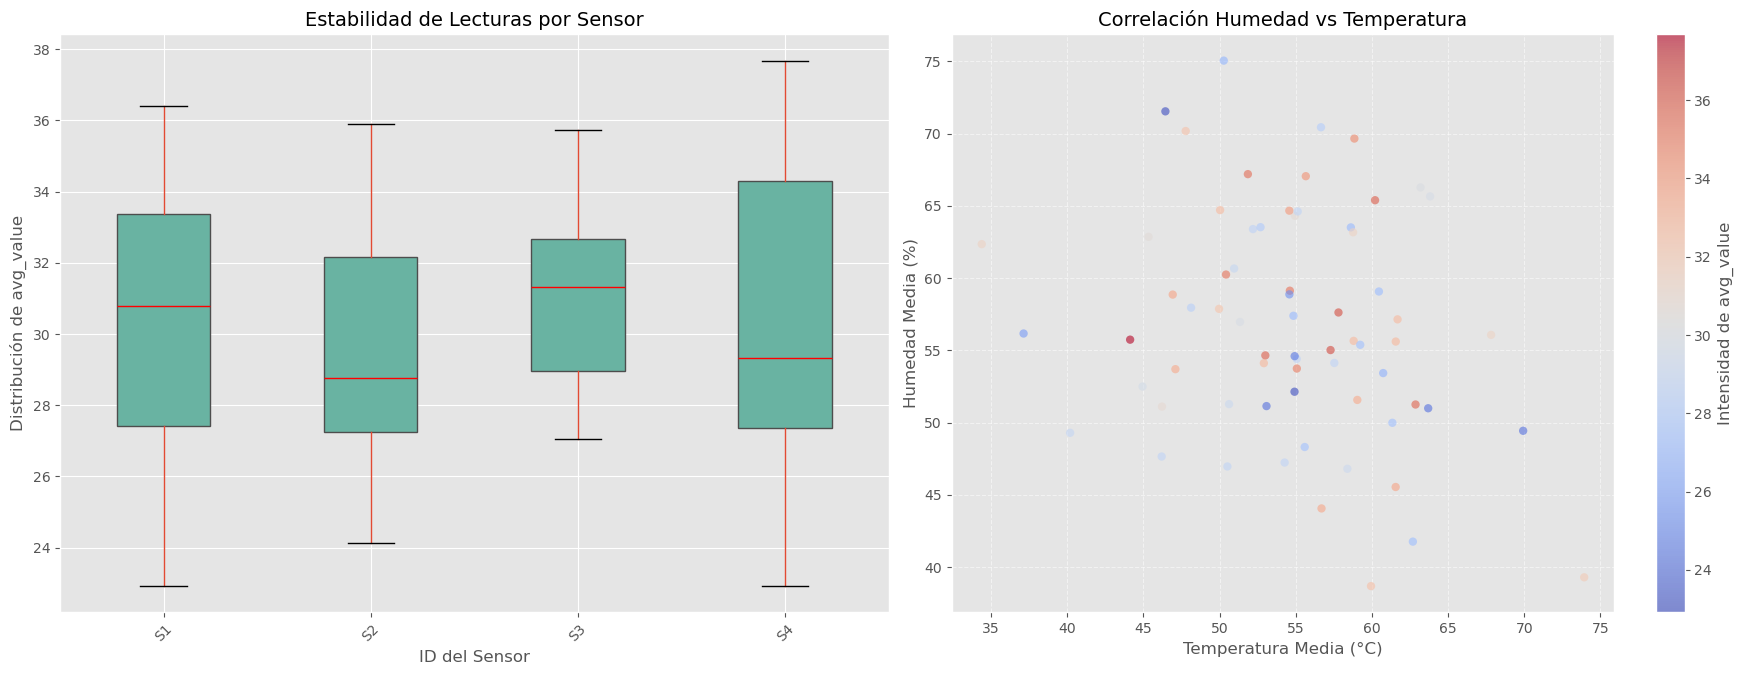

In [49]:
import matplotlib.pyplot as plt

pdf = df_resultados.toPandas()


plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))


pdf.boxplot(column='avg_value', by='sensor_id', ax=ax1, 
            patch_artist=True, 
            boxprops=dict(facecolor='#69b3a2', color='#4d4d4d'),
            medianprops=dict(color='red'))

ax1.set_title('Estabilidad de Lecturas por Sensor', fontsize=14)
ax1.set_xlabel('ID del Sensor')
ax1.set_ylabel('Distribución de avg_value')
ax1.tick_params(axis='x', rotation=45)
# Limpiamos el título automático que genera pandas
plt.suptitle('') 


scatter = ax2.scatter(
    pdf['avg_temp'], 
    pdf['avg_humidity'], 
    c=pdf['avg_value'], 
    cmap='coolwarm', 
    alpha=0.6, 
    edgecolors='none'
)

# Añadimos barra de color
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Intensidad de avg_value')

ax2.set_title('Correlación Humedad vs Temperatura', fontsize=14)
ax2.set_xlabel('Temperatura Media (°C)')
ax2.set_ylabel('Humedad Media (%)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()